<a href="https://colab.research.google.com/github/saranyav02/Computational_Pharmacology/blob/main/Neural_ODEs_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 21%|██▏       | 64/300 [00:00<00:00, 312.48it/s]

Epoch 10/300, Loss: 561.087891
Epoch 20/300, Loss: 457.577942
Epoch 30/300, Loss: 333.642517
Epoch 40/300, Loss: 116.285904
Epoch 50/300, Loss: 47.945770
Epoch 60/300, Loss: 25.058781
Epoch 70/300, Loss: 18.742380


 43%|████▎     | 128/300 [00:00<00:00, 305.71it/s]

Epoch 80/300, Loss: 8.326282
Epoch 90/300, Loss: 7.593270
Epoch 100/300, Loss: 6.993549
Epoch 110/300, Loss: 6.469904
Epoch 120/300, Loss: 6.100736
Epoch 130/300, Loss: 5.849935
Epoch 140/300, Loss: 5.681107


 63%|██████▎   | 189/300 [00:00<00:00, 279.96it/s]

Epoch 150/300, Loss: 5.557182
Epoch 160/300, Loss: 5.455059
Epoch 170/300, Loss: 5.379189
Epoch 180/300, Loss: 5.317865
Epoch 190/300, Loss: 5.262451


 82%|████████▏ | 247/300 [00:00<00:00, 260.08it/s]

Epoch 200/300, Loss: 5.210644
Epoch 210/300, Loss: 5.161664
Epoch 220/300, Loss: 5.122374
Epoch 230/300, Loss: 5.087358
Epoch 240/300, Loss: 5.053005


100%|██████████| 300/300 [00:01<00:00, 277.12it/s]

Epoch 250/300, Loss: 5.019404
Epoch 260/300, Loss: 4.986389
Epoch 270/300, Loss: 4.953501
Epoch 280/300, Loss: 4.920223
Epoch 290/300, Loss: 4.888133
Epoch 300/300, Loss: 4.859145


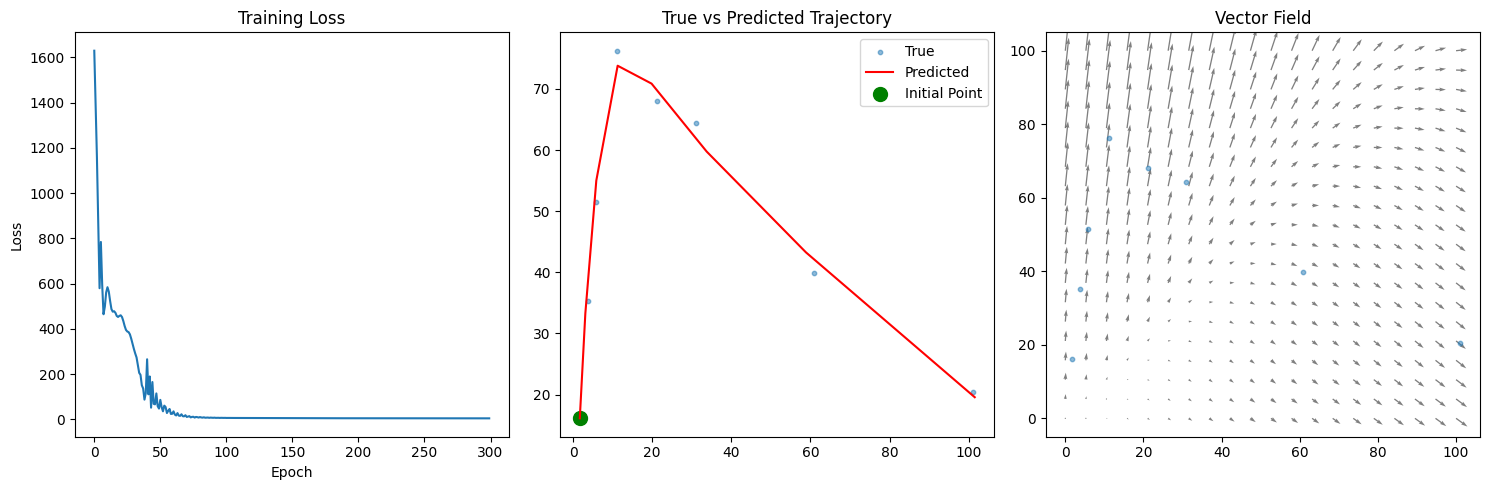

Training complete!


In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import math

class ODEFunc(nn.Module):
    def __init__(self, hidden_dim, augment_dim=1):
        super(ODEFunc, self).__init__()
        self.augment_dim = augment_dim
        self.net = nn.Sequential(
            nn.Linear(2 + self.augment_dim, hidden_dim),
            nn.ELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ELU(),
            nn.Linear(hidden_dim, 2 + self.augment_dim)
        )

    def forward(self, t, x):
        return self.net(x)

class ODESolver(nn.Module):
    def __init__(self, func, method='euler', augment_dim=1):
        super(ODESolver, self).__init__()
        self.func = func
        self.method = method
        self.augment_dim = augment_dim

    def forward(self, x0, t):
        h = t[1] - t[0]  # Assuming uniform time steps
        trajectory = [x0]
        x = x0

        for i in range(len(t) - 1):
            if self.method == 'euler':
                # Simple Euler method
                dx = self.func(t[i], x) * h
                x = x + dx
            elif self.method == 'rk4':
                # 4th-order Runge-Kutta method
                k1 = self.func(t[i], x)
                k2 = self.func(t[i] + h/2, x + h/2 * k1)
                k3 = self.func(t[i] + h/2, x + h/2 * k2)
                k4 = self.func(t[i] + h, x + h * k3)
                dx = h/6 * (k1 + 2*k2 + 2*k3 + k4)
                x = x + dx

            trajectory.append(x)

        return torch.stack(trajectory)

#simple drug absorption (exponential decay)
def generate_exp_data(n_points=100, noise=0.1): #change/ add pharmokinetic context (should be time series data?)
    theta = np.linspace(0, 3 * np.pi, n_points)
    t=np.linspace(0,1,n_points)
    z=math.e**(-t)+np.random.normal(0, noise, n_points)
    return np.column_stack((t,z))

#experimental data
def cocaine_data():
  t=[1.7094301899366897,3.768743752082635, 5.794735088303895, 11.136287904031988,21.1562812395868, 30.999666777740753,60.833055648117295, 101.06964345218262]
  x=[16.111296234588465, 35.27157614128622, 51.532822392535806, 76.24791736087968, 67.9873375541486, 64.36187937354214, 39.86671109630121, 20.449850049983297]
  return np.column_stack((t,x))


def main(): #goal is to predict data points given just initial data points
    torch.manual_seed(42)
    np.random.seed(42)

    augment_dim = 2  # Number of augmented dimensions to add > extra states for network to help learn next state

    n_points = 50
    exp_data = generate_exp_data(n_points=n_points, noise=0.1)
    exp_data = torch.tensor(exp_data, dtype=torch.float32)

    t = torch.linspace(0, 1, n_points)

    func = ODEFunc(hidden_dim=100, augment_dim=augment_dim)
    ode_solver = ODESolver(func, method='euler', augment_dim=augment_dim)

    # Initial condition (starting point of the spiral) with augmented dimensions
    x0_aug = torch.zeros(1, 2 + augment_dim, dtype=torch.float32)
    x0_aug[0, :2] = exp_data[0]  # Copy original dimensions
    x0 = x0_aug

    optimizer = optim.Adam(func.parameters(), lr=0.01)

    # Training loop
    n_epochs = 300
    losses = []

    for epoch in tqdm(range(n_epochs)):
        optimizer.zero_grad()
        pred_trajectory = ode_solver(x0, t)

        # Loss is MSE between predicted and true trajectory (only for original dimensions)
        loss = nn.MSELoss()(pred_trajectory[:, :, :2].squeeze(), exp_data)

        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch+1}/{n_epochs}, Loss: {loss.item():.6f}')

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.plot(losses)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss')

    # Plot true vs predicted trajectories
    plt.subplot(1, 3, 2)
    pred_trajectory_np = pred_trajectory.detach().squeeze().numpy()[:, :2]  # Only use original dimensions
    exp_data_np = exp_data.numpy()

    plt.scatter(exp_data_np[:, 0], exp_data_np[:, 1], label='True', s=10, alpha=0.5)
    plt.plot(pred_trajectory_np[:, 0], pred_trajectory_np[:, 1], 'r-', label='Predicted')
    plt.scatter(x0.detach().numpy()[0, 0], x0.detach().numpy()[0, 1], c='g', s=100, label='Initial Point')
    plt.legend()
    plt.title('True vs Predicted Trajectory')

    # Plot vector field
    plt.subplot(1, 3, 3)

    x = np.linspace(0, 1, 20)
    y = np.linspace(0, 1, 20)
    X, Y = np.meshgrid(x, y)

    # Compute vector field - we need to augment these points too
    grid_points = np.stack([X.flatten(), Y.flatten()], axis=1)
    grid_points_aug = np.zeros((grid_points.shape[0], 2 + augment_dim))
    grid_points_aug[:, :2] = grid_points  # Only set the first 2 dimensions

    grid_points_tensor = torch.tensor(grid_points_aug, dtype=torch.float32)

    with torch.no_grad():
        derivatives = func(0, grid_points_tensor).numpy()

    # We're only interested in visualizing the derivatives of the original dimensions
    U = derivatives[:, 0].reshape(X.shape)
    V = derivatives[:, 1].reshape(X.shape)

    plt.quiver(X, Y, U, V, alpha=0.5)
    plt.scatter(exp_data_np[:, 0], exp_data_np[:, 1], label='True', s=10, alpha=0.5)
    plt.title('Vector Field')


    plt.tight_layout()
    plt.show()

    print("Training complete!")

def main_real(): #goal is to predict data points given just initial data points
    torch.manual_seed(42)
    np.random.seed(42)

    augment_dim = 2  # Number of augmented dimensions to add > extra states for network to help learn next state

    n_points = 8

    real_data = cocaine_data()
    real_data = torch.tensor(real_data, dtype=torch.float32)

    t = torch.linspace(0, 1, n_points)

    func = ODEFunc(hidden_dim=100, augment_dim=augment_dim)
    ode_solver = ODESolver(func, method='euler', augment_dim=augment_dim)

    # Initial condition (starting point of the spiral) with augmented dimensions
    x0_aug = torch.zeros(1, 2 + augment_dim, dtype=torch.float32)
    x0_aug[0, :2] = real_data[0]  # Copy original dimensions
    x0 = x0_aug

    optimizer = optim.Adam(func.parameters(), lr=0.01)

    # Training loop
    n_epochs = 300
    losses = []

    for epoch in tqdm(range(n_epochs)):
        optimizer.zero_grad()
        pred_trajectory = ode_solver(x0, t)

        # Loss is MSE between predicted and true trajectory (only for original dimensions)
        loss = nn.MSELoss()(pred_trajectory[:, :, :2].squeeze(), real_data)

        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch+1}/{n_epochs}, Loss: {loss.item():.6f}')

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.plot(losses)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss')

    # Plot true vs predicted trajectories
    plt.subplot(1, 3, 2)
    pred_trajectory_np = pred_trajectory.detach().squeeze().numpy()[:, :2]  # Only use original dimensions
    real_data_np = real_data.numpy()

    plt.scatter(real_data_np[:, 0], real_data_np[:, 1], label='True', s=10, alpha=0.5)
    plt.plot(pred_trajectory_np[:, 0], pred_trajectory_np[:, 1], 'r-', label='Predicted')
    plt.scatter(x0.detach().numpy()[0, 0], x0.detach().numpy()[0, 1], c='g', s=100, label='Initial Point')
    plt.legend()
    plt.title('True vs Predicted Trajectory')

    # Plot vector field
    plt.subplot(1, 3, 3)

    x = np.linspace(0,100, 20)
    y = np.linspace(0,100, 20)
    X, Y = np.meshgrid(x, y)

    # Compute vector field - we need to augment these points too
    grid_points = np.stack([X.flatten(), Y.flatten()], axis=1)
    grid_points_aug = np.zeros((grid_points.shape[0], 2 + augment_dim))
    grid_points_aug[:, :2] = grid_points  # Only set the first 2 dimensions

    grid_points_tensor = torch.tensor(grid_points_aug, dtype=torch.float32)

    with torch.no_grad():
        derivatives = func(0, grid_points_tensor).numpy()

    # We're only interested in visualizing the derivatives of the original dimensions
    U = derivatives[:, 0].reshape(X.shape)
    V = derivatives[:, 1].reshape(X.shape)

    plt.quiver(X, Y, U, V, alpha=0.5)
    plt.scatter(real_data_np[:, 0], real_data_np[:, 1], label='True', s=10, alpha=0.5)
    plt.title('Vector Field')


    plt.tight_layout()
    plt.show()

    print("Training complete!")


main_real()